# Projeto: Modelo Preditivo de Vulnerabilidade à Violência Doméstica contra a Mulher

**Notebook unificado para execução local** — sem dependências do Google Drive/Colab.

### Estrutura de pastas esperada
Os dados serão baixados e salvos em:
```
dados_violencia/
├── sinan/por_ano/    ← arquivos VIOLBR10.parquet … VIOLBR24.parquet
├── pnad/             ← pnad_2019_mulheres.parquet
├── ipea/             ← idh_municipal_2010.parquet
└── final/            ← df_final.parquet  (gerado pelo notebook)
```
Ajuste `PASTA_BASE` na célula seguinte se quiser outro caminho.

Python Version: 3.10.11

In [4]:
# ── CONFIGURAÇÃO DE CAMINHOS ────────────────────────────────
import os

PASTA_BASE   = os.path.join(os.getcwd(), 'dados_violencia')
PASTA_SINAN  = os.path.join(PASTA_BASE, 'sinan', 'por_ano')
PASTA_PNAD   = os.path.join(PASTA_BASE, 'pnad')
PASTA_IPEA   = os.path.join(PASTA_BASE, 'ipea')
PASTA_FINAL  = os.path.join(PASTA_BASE, 'final')
PASTA_MODELOS = os.path.join(PASTA_BASE, 'modelos')

PNAD = os.path.join(PASTA_PNAD, 'pnad_2019_mulheres.parquet')
IDH  = os.path.join(PASTA_IPEA, 'idh_municipal_2010.parquet')
DF_FINAL = os.path.join(PASTA_FINAL, 'df_final.parquet')

for p in [PASTA_SINAN, PASTA_PNAD, PASTA_IPEA, PASTA_FINAL, PASTA_MODELOS]:
    os.makedirs(p, exist_ok=True)

print('Caminhos configurados:')
print(f'  SINAN  : {PASTA_SINAN}')
print(f'  PNAD   : {PNAD}')
print(f'  IDH    : {IDH}')
print(f'  SAÍDA  : {DF_FINAL}')


Caminhos configurados:
  SINAN  : c:\Users\Wallace Luan\Downloads\Projeto - Modelo Preditivo\dados_violencia\sinan\por_ano
  PNAD   : c:\Users\Wallace Luan\Downloads\Projeto - Modelo Preditivo\dados_violencia\pnad\pnad_2019_mulheres.parquet
  IDH    : c:\Users\Wallace Luan\Downloads\Projeto - Modelo Preditivo\dados_violencia\ipea\idh_municipal_2010.parquet
  SAÍDA  : c:\Users\Wallace Luan\Downloads\Projeto - Modelo Preditivo\dados_violencia\final\df_final.parquet


## SEÇÃO 1 — Instalação de dependências

In [20]:
import subprocess, sys

pacotes = [
    'readdbc', 'dbfread', 'pandas', 'pyarrow',
    'scikit-learn', 'matplotlib', 'seaborn',
    'xgboost', 'lightgbm', 'shap', 'joblib',
    'requests', 'beautifulsoup4', 'xlrd>=2.0.1', 'openpyxl'
]

falhas = []
for p in pacotes:
    print(f'Instalando {p}...')
    proc = subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'],
                          stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if proc.returncode != 0:
        print(f'  ERRO ao instalar {p}: {proc.stderr.strip()[:500]}')
        print('  Tentando novamente sem -q para obter mensagem completa...')
        proc2 = subprocess.run([sys.executable, '-m', 'pip', 'install', p], stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
        if proc2.returncode != 0:
            print(f'  Falha persistente em {p}: {proc2.stderr.strip()[:1000]}')
            falhas.append(p)
        else:
            print(f'  OK (segunda tentativa) — {p}')
    else:
        print(f'  OK — {p}')

if falhas:
    print('\nPacotes com falha na instalação:')
    for p in falhas:
        print(' -', p)
    print('Tente instalar manualmente ou verificar a conexão/versão do Python.')
else:
    print('\nDependências instaladas com sucesso.')


Instalando readdbc...
  OK — readdbc
Instalando dbfread...
  OK — dbfread
Instalando pandas...
  OK — pandas
Instalando pyarrow...
  OK — pyarrow
Instalando scikit-learn...
  OK — scikit-learn
Instalando matplotlib...
  OK — matplotlib
Instalando seaborn...
  OK — seaborn
Instalando xgboost...
  OK — xgboost
Instalando lightgbm...
  OK — lightgbm
Instalando shap...
  OK — shap
Instalando joblib...
  OK — joblib
Instalando requests...
  OK — requests
Instalando beautifulsoup4...
  OK — beautifulsoup4
Instalando xlrd>=2.0.1...
  OK — xlrd>=2.0.1
Instalando openpyxl...
  OK — openpyxl

Dependências instaladas com sucesso.


In [7]:
# Verificar se readdbc está instalado e, se necessário, reinstalá-lo.
import sys, subprocess

try:
    import readdbc
    print('✓ readdbc importado com sucesso.')
except Exception as e:
    print('✗ Falha ao importar readdbc:', e)
    print('\nTentativa 1: Reinstalar readdbc via pip...')
    proc = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '--upgrade', '--force-reinstall', 'readdbc'],
        stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, timeout=60
    )
    if proc.returncode == 0:
        print('✓ readdbc reinstalado com sucesso.')
        import importlib
        import readdbc
        importlib.reload(readdbc)
    else:
        print('✗ Falha ao reinstalar via pip.')
        print('\nTentativa 2: Instalar via pipwin (wheels pré-compilados)...')
        try:
            # Instalar pipwin
            proc_pipwin = subprocess.run(
                [sys.executable, '-m', 'pip', 'install', 'pipwin'],
                stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, timeout=30
            )
            if proc_pipwin.returncode == 0:
                print('✓ pipwin instalado.')
                # Instalar readdbc via pipwin
                proc_readdbc = subprocess.run(
                    [sys.executable, '-m', 'pipwin', 'install', 'readdbc'],
                    stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, timeout=60
                )
                if proc_readdbc.returncode == 0:
                    print('✓ readdbc instalado via pipwin.')
                    import importlib
                    import readdbc
                    importlib.reload(readdbc)
                else:
                    print('✗ Falha ao instalar readdbc via pipwin.')
                    print('  Erro:', proc_readdbc.stderr[:500])
            else:
                print('✗ Falha ao instalar pipwin.')
        except Exception as e2:
            print(f'✗ Erro com pipwin: {e2}')
        
        print('\n⚠️  SOLUÇÃO MANUAL:')
        print('1. Instale Microsoft C++ Build Tools:')
        print('   https://visualstudio.microsoft.com/visual-cpp-build-tools/')
        print('2. OU use 7-Zip para extrair manualmente os arquivos .dbf dos arquivos .dbc')
        print('3. OU instale Anaconda/Miniconda e use: conda install -c conda-forge readdbc')
        print('\nA próxima célula tentará usar alternativas (dbfread + 7-Zip/conversão manual).')


✓ readdbc importado com sucesso.


## SEÇÃO 2 — Download dos dados SINAN (DataSUS, 2010–2024)

### ⚠️ Se receber erro "Visual C++ 14.0 or greater is required":

**Solução 1 (Recomendada — Use Anaconda):**
```powershell
conda install -c conda-forge readdbc
```

**Solução 2: Instale o Microsoft C++ Build Tools**
1. Acesse: https://visualstudio.microsoft.com/visual-cpp-build-tools/
2. Baixe e execute o instalador
3. Selecione "C++ build tools" durante a instalação
4. Reinicie o notebook após a instalação

**Solução 3: Use 7-Zip para extrair manualmente**
1. Baixe 7-Zip: https://www.7-zip.org/
2. Extraia cada arquivo `VIOLBR*.dbc` para obter `VIOLBR*.dbf`
3. Coloque os `.dbf` em `dados_violencia/sinan/por_ano/`
4. A próxima célula vai processar os `.dbf` automaticamente

**Solução 4: Use Anaconda (ambiente limpo)**
```powershell
conda create -n sinan_env python=3.10 -c conda-forge readdbc pandas pyarrow dbfread -y
conda activate sinan_env
python -m jupyter notebook  # execute este notebook no env sinan_env
```


In [38]:
import os

pasta_destino = PASTA_SINAN.replace('/por_ano', '')
pasta_dbc = os.path.join(PASTA_BASE, 'sinan_dbc')
os.makedirs(pasta_dbc, exist_ok=True)

anos = [str(ano)[2:] for ano in range(2010, 2025)]

print('Iniciando download do SINAN via FTP do DataSUS...')
print(f'Destino: {pasta_dbc}\n')

for ano in anos:
    arquivo = f'VIOLBR{ano}.dbc'
    caminho_salvar = os.path.join(pasta_dbc, arquivo)

    url_final = f"ftp://ftp.datasus.gov.br/dissemin/publicos/SINAN/DADOS/FINAIS/{arquivo}"
    url_prelim = f"ftp://ftp.datasus.gov.br/dissemin/publicos/SINAN/DADOS/PRELIM/{arquivo}"

    if os.path.exists(caminho_salvar) and os.path.getsize(caminho_salvar) > 0:
        print(f'  {arquivo} já existe. Pulando.')
        continue

    print(f'Baixando {arquivo}...')
    if os.path.exists(caminho_salvar) and os.path.getsize(caminho_salvar) > 0:
        print(f'  {arquivo} já existe localmente. Pulando download.')
        continue

    from ftplib import FTP, error_perm

    ftp_host = 'ftp.datasus.gov.br'
    encontrado = False
    try:
        with FTP(ftp_host, timeout=30) as ftp:
            ftp.login()
            for remote_base in ['dissemin/publicos/SINAN/DADOS/FINAIS', 'dissemin/publicos/SINAN/DADOS/PRELIM']:
                try:
                    ftp.cwd(remote_base)
                    try:
                        files = ftp.nlst()
                    except Exception:
                        files = []
                    if arquivo in files:
                        with open(caminho_salvar, 'wb') as f:
                            ftp.retrbinary(f'RETR {arquivo}', f.write)
                        if os.path.exists(caminho_salvar) and os.path.getsize(caminho_salvar) > 0:
                            print(f'  OK — baixado de {remote_base} ({os.path.getsize(caminho_salvar)/1024:.1f} KB)')
                            encontrado = True
                            break
                except error_perm:
                    # diretório não existe ou sem permissão
                    continue
    except Exception as e:
        print('  Erro ao conectar ao FTP:', e)

    if not encontrado:
        print(f'  ERRO — ano 20{ano} não disponível.')

print('\nDownload concluído.')


Iniciando download do SINAN via FTP do DataSUS...
Destino: c:\Users\Wallace Luan\Downloads\Projeto - Modelo Preditivo\dados_violencia\sinan_dbc

Baixando VIOLBR10.dbc...
  OK — baixado de dissemin/publicos/SINAN/DADOS/FINAIS (4112.8 KB)
Baixando VIOLBR11.dbc...
  OK — baixado de dissemin/publicos/SINAN/DADOS/FINAIS (6130.5 KB)
Baixando VIOLBR12.dbc...
  OK — baixado de dissemin/publicos/SINAN/DADOS/FINAIS (8846.4 KB)
Baixando VIOLBR13.dbc...
  OK — baixado de dissemin/publicos/SINAN/DADOS/FINAIS (10695.2 KB)
Baixando VIOLBR14.dbc...
  OK — baixado de dissemin/publicos/SINAN/DADOS/FINAIS (13297.4 KB)
Baixando VIOLBR15.dbc...
  OK — baixado de dissemin/publicos/SINAN/DADOS/FINAIS (14501.7 KB)
Baixando VIOLBR16.dbc...
  OK — baixado de dissemin/publicos/SINAN/DADOS/FINAIS (13034.4 KB)
Baixando VIOLBR17.dbc...
  OK — baixado de dissemin/publicos/SINAN/DADOS/FINAIS (17990.4 KB)
Baixando VIOLBR18.dbc...
  OK — baixado de dissemin/publicos/SINAN/DADOS/FINAIS (25823.6 KB)
Baixando VIOLBR19.dbc

## SEÇÃO 3 — Conversão DBC → Parquet

In [22]:
import pandas as pd
import os
import readdbc
import gc
from dbfread import DBF

pasta_dbc     = os.path.join(PASTA_BASE, 'sinan_dbc')
pasta_parquet = PASTA_SINAN

arquivos = sorted([
    f for f in os.listdir(pasta_dbc)
    if f.endswith('.dbc') and os.path.getsize(os.path.join(pasta_dbc, f)) > 0
])

print(f"Total de arquivos para converter: {len(arquivos)}\n")

for arquivo in arquivos:
    nome_base             = arquivo.replace('.dbc', '')
    caminho_dbc           = os.path.join(pasta_dbc, arquivo)
    caminho_dbf_temp      = os.path.join(PASTA_BASE, f"{nome_base}.dbf")
    caminho_parquet_final = os.path.join(pasta_parquet, f"{nome_base}.parquet")

    # Pula arquivos já convertidos (permite reexecução segura da célula)
    if os.path.exists(caminho_parquet_final):
        print(f"  {arquivo} já convertido. Pulando.")
        continue

    try:
        # Passo 1: descompactar .dbc → .dbf
        readdbc.dbc2dbf(caminho_dbc, caminho_dbf_temp)

        # Passo 2: ler .dbf e converter para DataFrame
        tabela_dbf = DBF(caminho_dbf_temp, encoding='iso-8859-1', load=True)
        df = pd.DataFrame(tabela_dbf.records)

        # Uniformiza tipos entre anos para evitar conflito de schema na junção
        df = df.astype(str)
        df['arquivo_origem'] = arquivo  # rastreabilidade do ano de origem

        # Passo 3: salvar em Parquet
        df.to_parquet(caminho_parquet_final, index=False)
        print(f"  OK — {arquivo}: {len(df):,} registros salvos.")

        # Liberação de memória RAM após cada arquivo
        del tabela_dbf, df
        if os.path.exists(caminho_dbf_temp):
            os.remove(caminho_dbf_temp)
        gc.collect()

    except Exception as e:
        print(f"  ERRO em {arquivo}: {e}")
        if os.path.exists(caminho_dbf_temp):
            os.remove(caminho_dbf_temp)

print("\nConversão concluída.")


Total de arquivos para converter: 15

  VIOLBR10.dbc já convertido. Pulando.
  VIOLBR11.dbc já convertido. Pulando.
  VIOLBR12.dbc já convertido. Pulando.
  VIOLBR13.dbc já convertido. Pulando.
  VIOLBR14.dbc já convertido. Pulando.
  VIOLBR15.dbc já convertido. Pulando.
  VIOLBR16.dbc já convertido. Pulando.
  VIOLBR17.dbc já convertido. Pulando.
  VIOLBR18.dbc já convertido. Pulando.
  VIOLBR19.dbc já convertido. Pulando.
  VIOLBR20.dbc já convertido. Pulando.
  VIOLBR21.dbc já convertido. Pulando.
  VIOLBR22.dbc já convertido. Pulando.
  VIOLBR23.dbc já convertido. Pulando.
  VIOLBR24.dbc já convertido. Pulando.

Conversão concluída.


## SEÇÃO 4 — Coleta da PNAD Contínua 2019 (IBGE)

In [23]:
import os, zipfile
import requests
from bs4 import BeautifulSoup

# Download do arquivo de microdados usando requests (mais robusto no Windows)
url_arquivo = (
    'https://ftp.ibge.gov.br/Trabalho_e_Rendimento/'
    'Pesquisa_Nacional_por_Amostra_de_Domicilios_continua/'
    'Anual/Microdados/Visita/Visita_1/Dados/'
    'PNADC_2019_visita1_20250822.zip'
)

zip_path = os.path.join(PASTA_PNAD, 'PNADC_2019.zip')
os.makedirs(PASTA_PNAD, exist_ok=True)

def download_url(url, path, timeout=60):
    try:
        with requests.get(url, stream=True, timeout=timeout) as r:
            r.raise_for_status()
            total = int(r.headers.get('content-length', 0))
            with open(path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
        return True
    except Exception as e:
        print('Erro no download:', e)
        return False

if not os.path.exists(zip_path) or os.path.getsize(zip_path) == 0:
    print('Baixando PNAD 2019 (~180 MB) via requests...')
    ok = download_url(url_arquivo, zip_path)
    if ok and os.path.exists(zip_path) and os.path.getsize(zip_path) > 0:
        print(f'Download concluído: {os.path.getsize(zip_path)/(1024*1024):.1f} MB')
    else:
        print('Falha no download com requests. Verifique conexão ou tente baixar manualmente do FTP do IBGE.')
else:
    print('PNAD já baixada.')

# Extração
txt_files = [f for f in os.listdir(PASTA_PNAD) if f.endswith('.txt')]
if not txt_files:
    if os.path.exists(zip_path) and os.path.getsize(zip_path) > 0:
        with zipfile.ZipFile(zip_path, 'r') as z:
            print('Conteúdo:', z.namelist())
            z.extractall(PASTA_PNAD)
        print(f'Extraído em: {PASTA_PNAD}')
    else:
        print('Arquivo zip ausente. Não foi possível extrair.')
else:
    print(f'Microdados já extraídos: {txt_files}')


PNAD já baixada.
Microdados já extraídos: ['PNADC_2019_visita1.txt']


In [24]:
# Download do dicionário de variáveis
url_dic = (
    'https://ftp.ibge.gov.br/Trabalho_e_Rendimento/'
    'Pesquisa_Nacional_por_Amostra_de_Domicilios_continua/'
    'Anual/Microdados/Visita/Visita_1/Documentacao/'
    'dicionario_PNADC_microdados_2019_visita1_20230811.xls'
)

dic_path = os.path.join(PASTA_PNAD, 'dicionario_2019.xls')

# Baixar dicionário via requests (mais robusto no Windows) se ausente
if not os.path.exists(dic_path):
    try:
        with requests.get(url_dic, stream=True, timeout=60) as r:
            r.raise_for_status()
            with open(dic_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
        print('Dicionário baixado com sucesso.')
    except Exception as e:
        print('Falha ao baixar dicionário:', e)
        print('Baixe manualmente de:', url_dic)

if os.path.exists(dic_path):
    print(f'Dicionário: {os.path.getsize(dic_path)/(1024*1024):.2f} MB')
else:
    print('Dicionário não disponível.')


Dicionário: 0.22 MB


In [25]:
import pandas as pd, numpy as np, os
import subprocess, sys

if not os.path.exists(dic_path):
    raise FileNotFoundError(f'Dicionário ausente: {dic_path}. Rode a célula de download ou baixe manualmente: {url_dic}')

# Tentar ler o dicionário; se faltar xlrd, instalar e tentar novamente
try:
    df_dic = pd.read_excel(dic_path, header=1)
except ImportError as e:
    print('ImportError ao ler Excel (provavelmente falta xlrd). Tentando instalar xlrd...')
    proc = subprocess.run([sys.executable, '-m', 'pip', 'install', 'xlrd>=2.0.1'], stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if proc.returncode != 0:
        raise RuntimeError(f'Falha ao instalar xlrd: {proc.stderr}') from e
    else:
        print('xlrd instalado. Recarregando pandas e tentando ler novamente...')
        import importlib
        importlib.reload(pd)
        df_dic = pd.read_excel(dic_path, header=1)

df_dic.columns = ['pos_ini','tamanho','variavel','quesito',
                  'descricao','categorias','cat_desc','periodo']
df_vars = df_dic[df_dic['variavel'].notna()][['variavel','pos_ini','tamanho']].copy()
df_vars['pos_ini'] = pd.to_numeric(df_vars['pos_ini'], errors='coerce')
df_vars['tamanho'] = pd.to_numeric(df_vars['tamanho'], errors='coerce')
df_vars = df_vars.dropna(subset=['pos_ini','tamanho'])

# Posições confirmadas (base 0 para pandas fwf)
colspecs = [
    (0,   4),    # Ano
    (5,   7),    # UF
    (93,  94),   # V2007 — sexo
    (102, 105),  # V2009 — idade
    (105, 106),  # V2010 — cor/raça
    (534, 535),  # VD3004 — escolaridade
    (580, 588),  # VD4020 — rendimento mensal
]
names = ['Ano','UF','V2007','V2009','V2010','VD3004','VD4020']

# Localizar o arquivo txt de microdados
txt_files = [f for f in os.listdir(PASTA_PNAD) if f.endswith('.txt')]
if not txt_files:
    raise FileNotFoundError('Arquivo de microdados PNAD não encontrado em ' + PASTA_PNAD)

pnad_txt = os.path.join(PASTA_PNAD, txt_files[0])
print(f'Lendo: {pnad_txt} (~2 min)...')

df_pnad = pd.read_fwf(pnad_txt, colspecs=colspecs, names=names, encoding='latin1')
print(f'Shape bruto: {df_pnad.shape}')

# Filtrar mulheres
df_pnad_f = df_pnad[df_pnad['V2007'] == 2].copy()
print(f'Registros de mulheres: {df_pnad_f.shape[0]:,}')

df_pnad_f['raca'] = df_pnad_f['V2010'].map(
    {1:'Branca',2:'Preta',3:'Amarela',4:'Parda',5:'Indigena',9:'Ignorado'}
)
df_pnad_f['escolaridade'] = df_pnad_f['VD3004'].map(
    {1:'Sem instrucao',2:'Fundamental incompleto',3:'Fundamental completo',
     4:'Medio incompleto',5:'Medio completo',6:'Superior incompleto',7:'Superior completo'}
)
df_pnad_f = df_pnad_f.rename(columns={'UF':'uf_cod','V2009':'idade','VD4020':'renda_mensal'})
df_final_pnad = df_pnad_f[['Ano','uf_cod','idade','raca','escolaridade','renda_mensal']].copy()

df_final_pnad.to_parquet(PNAD, index=False)
print(f'\nPNAD salva: {df_final_pnad.shape}')


Lendo: c:\Users\Wallace Luan\Downloads\Projeto - Modelo Preditivo\dados_violencia\pnad\PNADC_2019_visita1.txt (~2 min)...
Shape bruto: (443790, 7)
Registros de mulheres: 226,936

PNAD salva: (226936, 6)


## SEÇÃO 5 — IDH Municipal (Atlas Brasil / Base dos Dados)

Baixe manualmente os arquivos abaixo em `dados_violencia/ipea/` e descompacte:
- `mundo_onu_adh_municipio.csv`
- `br_bd_diretorios_brasil_municipio.csv`

Fonte: https://basedosdados.org (tabelas públicas do Atlas do Desenvolvimento Humano)

In [26]:
import pandas as pd, os

# Verificar arquivos IDH
esperados = ['mundo_onu_adh_municipio.csv', 'br_bd_diretorios_brasil_municipio.csv']
for f in esperados:
    caminho = os.path.join(PASTA_IPEA, f)
    if os.path.exists(caminho):
        print(f'OK — {f} ({os.path.getsize(caminho)/(1024*1024):.1f} MB)')
    else:
        print(f'FALTANDO — {f}')
        print(f'  Baixe de https://basedosdados.org e salve em: {PASTA_IPEA}')


OK — mundo_onu_adh_municipio.csv (17.8 MB)
OK — br_bd_diretorios_brasil_municipio.csv (1.3 MB)


In [27]:
import pandas as pd, os

idh_csv = os.path.join(PASTA_IPEA, 'mundo_onu_adh_municipio.csv')
dir_csv  = os.path.join(PASTA_IPEA, 'br_bd_diretorios_brasil_municipio.csv')

df_idh = pd.read_csv(idh_csv)
df_idh = df_idh[df_idh['ano'] == 2010][[
    'id_municipio','idhm','idhm_e','idhm_l','idhm_r',
    'renda_pc','indice_gini','prop_pobreza',
    'taxa_analfabetismo_15_mais','populacao','populacao_mulheres'
]].copy()

df_dir = pd.read_csv(dir_csv)[[
    'id_municipio','id_municipio_6','nome',
    'sigla_uf','nome_uf','nome_regiao','capital_uf'
]].copy()

df_mun = df_idh.merge(df_dir, on='id_municipio', how='left')
df_mun['cod_mun6'] = df_mun['id_municipio_6'].astype(str).str.zfill(6)

df_mun.to_parquet(IDH, index=False)
print(f'IDH municipal salvo: {df_mun.shape}')
print(df_mun[['cod_mun6','nome','sigla_uf','idhm','renda_pc']].head(3))


IDH municipal salvo: (5565, 18)
  cod_mun6                   nome sigla_uf   idhm  renda_pc
0   110001  Alta Floresta D'Oeste       RO  0.641    476.99
1   110002              Ariquemes       RO  0.702    689.95
2   110003                 Cabixi       RO  0.650    457.17


## SEÇÃO 6 — Limpeza e Tratamento do SINAN

In [28]:
import pandas as pd, numpy as np, os

COLUNAS_SINAN = [
    'CS_SEXO','NU_IDADE_N','CS_RACA','CS_ESCOL_N','SIT_CONJUG',
    'ID_MN_RESI','SG_UF','arquivo_origem','DT_NOTIFIC',
    'REL_CONJ','REL_EXCON','REL_NAMO','REL_EXNAM',
    'REL_PAI','REL_PADR','REL_MAD','REL_FILHO','REL_IRMAO',
    'REL_CONHEC','REL_DESCO','REL_OUTROS',
    'VIOL_FISIC','VIOL_PSICO','VIOL_SEXU','VIOL_FINAN','VIOL_NEGLI',
    'OUT_VEZES','AUTOR_SEXO','AUTOR_ALCO',
    'ENC_DEAM','ENC_DELEG','ENC_CREAS','ENC_MULHER',
    'CONS_SUIC','CONS_MENT','EVOLUCAO',
]

arquivos = sorted([f for f in os.listdir(PASTA_SINAN) if f.endswith('.parquet')])
dfs = []

for f in arquivos:
    df_ano = pd.read_parquet(os.path.join(PASTA_SINAN, f))
    cols = [c for c in COLUNAS_SINAN if c in df_ano.columns]
    if len(cols) == 0:
        print(f'  Aviso: {f} não contém colunas esperadas; pulando.')
        continue
    dfs.append(df_ano[cols])
    print(f'{f} — {len(df_ano):,} registros | {len(cols)} colunas')

if not dfs:
    print('Nenhum DataFrame válido para concatenar (nenhum parquet com as colunas esperadas).')
    print('Arquivos encontrados em', PASTA_SINAN, ':', sorted(os.listdir(PASTA_SINAN)))
    raise FileNotFoundError('Nenhum arquivo parquet válido do SINAN encontrado. Execute a conversão DBC→Parquet primeiro.')

df_sinan = pd.concat(dfs, ignore_index=True)
df_sinan = df_sinan[df_sinan['CS_SEXO'] == 'F'].copy()

print(f'\nShape final (só mulheres): {df_sinan.shape}')


VIOLBR10.parquet — 73,794 registros | 35 colunas
VIOLBR11.parquet — 107,530 registros | 35 colunas
VIOLBR12.parquet — 157,033 registros | 35 colunas
VIOLBR13.parquet — 188,728 registros | 35 colunas
VIOLBR14.parquet — 198,113 registros | 35 colunas
VIOLBR15.parquet — 227,901 registros | 35 colunas
VIOLBR16.parquet — 243,259 registros | 35 colunas
VIOLBR17.parquet — 307,367 registros | 35 colunas
VIOLBR18.parquet — 350,354 registros | 35 colunas
VIOLBR19.parquet — 405,497 registros | 35 colunas
VIOLBR20.parquet — 326,503 registros | 35 colunas
VIOLBR21.parquet — 373,262 registros | 35 colunas
VIOLBR22.parquet — 442,680 registros | 35 colunas
VIOLBR23.parquet — 588,388 registros | 35 colunas
VIOLBR24.parquet — 616,548 registros | 35 colunas

Shape final (só mulheres): (3284999, 35)


In [29]:
# Mapeamento e limpeza
df = df_sinan.copy()

# Idade
df['NU_IDADE_N'] = df['NU_IDADE_N'].astype(str).str.strip()
df['idade'] = pd.to_numeric(df['NU_IDADE_N'], errors='coerce')
mask_anos = df['NU_IDADE_N'].str.startswith('4')
df.loc[mask_anos, 'idade'] = df.loc[mask_anos, 'NU_IDADE_N'].str[1:].astype(float)
df.loc[~mask_anos, 'idade'] = np.nan

# Raça
mapa_raca = {'1':'Branca','2':'Preta','3':'Amarela','4':'Parda','5':'Indigena','9':'Ignorado','':'Ignorado'}
df['raca'] = df['CS_RACA'].astype(str).str.strip().map(mapa_raca).fillna('Ignorado')

# Escolaridade
mapa_escol = {
    '00':'Sem instrucao','01':'Sem instrucao',
    '02':'Fundamental incompleto','03':'Fundamental incompleto',
    '04':'Fundamental completo','05':'Medio incompleto',
    '06':'Medio completo','07':'Superior incompleto',
    '08':'Superior completo','09':'Ignorado','10':'Ignorado',
    '9':'Ignorado','':'Ignorado'
}
df['escolaridade'] = df['CS_ESCOL_N'].astype(str).str.strip().map(mapa_escol).fillna('Ignorado')

# Situação conjugal
mapa_conjug = {'1':'Solteira','2':'Casada/Uniao estavel','3':'Viuva',
               '4':'Separada','8':'Nao se aplica','9':'Ignorado','':'Ignorado'}
df['sit_conjugal'] = df['SIT_CONJUG'].astype(str).str.strip().map(mapa_conjug).fillna('Ignorado')

# Reincidência
mapa_reincid = {'1':'Sim','2':'Nao','9':'Ignorado','':'Ignorado','0':'Nao'}
df['reincidencia'] = df['OUT_VEZES'].astype(str).str.strip().map(mapa_reincid).fillna('Ignorado')

# Álcool agressor
mapa_alco = {'1':'Sim','2':'Nao','9':'Ignorado','':'Ignorado'}
df['agressor_alcool'] = df['AUTOR_ALCO'].astype(str).str.strip().map(mapa_alco).fillna('Ignorado')

# Evolução
mapa_evolucao = {'1':'Cura','2':'Obito por violencia','3':'Obito por outras causas',
                 '4':'Perda de seguimento','9':'Ignorado','':'Ignorado'}
df['evolucao'] = df['EVOLUCAO'].astype(str).str.strip().map(mapa_evolucao).fillna('Ignorado')

# Faixa etária
bins   = [0,17,24,34,44,54,64,120]
labels = ['menor_18','18_24','25_34','35_44','45_54','55_64','65_mais']
df['faixa_etaria'] = pd.cut(df['idade'], bins=bins, labels=labels)

# Relação com agressor
def rel_agressor(row):
    for col, label in [
        ('REL_CONJ','Conjuge'),('REL_EXCON','Ex_conjuge'),
        ('REL_NAMO','Namorado'),('REL_EXNAM','Ex_namorado'),
        ('REL_PAI','Pai'),('REL_FILHO','Filho'),
        ('REL_IRMAO','Irmao'),('REL_CONHEC','Conhecido'),
        ('REL_DESCO','Desconhecido'),('REL_OUTROS','Outros'),
    ]:
        if col in row and row[col] == '1':
            return label
    return 'Ignorado'

print('Criando coluna relacao_agressor...')
df['relacao_agressor'] = df.apply(rel_agressor, axis=1)

# Variáveis binárias
for col in ['VIOL_FISIC','VIOL_PSICO','VIOL_SEXU','VIOL_FINAN','VIOL_NEGLI',
            'ENC_DEAM','ENC_DELEG','ENC_CREAS','ENC_MULHER',
            'CONS_SUIC','CONS_MENT']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().map({'1':1,'2':0,'9':0}).fillna(0).astype(int)

# Flag parceiro íntimo
df['parceiro_intimo'] = df['relacao_agressor'].isin(
    ['Conjuge','Ex_conjuge','Namorado','Ex_namorado']
).astype(int)

print(f'Tratamento concluído. Shape: {df.shape}')


Criando coluna relacao_agressor...
Tratamento concluído. Shape: (3284999, 45)


In [30]:
# Join com IDH Municipal
df['cod_mun6'] = df['ID_MN_RESI'].astype(str).str.strip().str[:6].str.zfill(6)

df_idh = pd.read_parquet(IDH)
df_idh['cod_mun6'] = df_idh['cod_mun6'].astype(str).str.zfill(6)

df_merged = df.merge(df_idh, on='cod_mun6', how='left')
print(f'Shape após join: {df_merged.shape}')
print(f'Missing idhm: {df_merged["idhm"].isnull().sum():,}')


Shape após join: (3284999, 63)
Missing idhm: 1,340


In [31]:
# Seleção e renomeação de colunas finais
COLUNAS_FINAIS = [
    'arquivo_origem','DT_NOTIFIC','SG_UF','cod_mun6','nome','nome_regiao',
    'idade','faixa_etaria','raca','escolaridade','sit_conjugal',
    'relacao_agressor','parceiro_intimo',
    'VIOL_FISIC','VIOL_PSICO','VIOL_SEXU','VIOL_FINAN','VIOL_NEGLI',
    'reincidencia','agressor_alcool',
    'ENC_DEAM','ENC_DELEG','ENC_CREAS','ENC_MULHER',
    'evolucao','CONS_SUIC','CONS_MENT',
    'idhm','idhm_e','idhm_l','idhm_r',
    'renda_pc','indice_gini','prop_pobreza','taxa_analfabetismo_15_mais',
]

cols_existentes = [c for c in COLUNAS_FINAIS if c in df_merged.columns]
df_final = df_merged[cols_existentes].copy()

df_final = df_final.rename(columns={
    'arquivo_origem':'ano','DT_NOTIFIC':'data_notificacao','SG_UF':'uf',
    'VIOL_FISIC':'viol_fisica','VIOL_PSICO':'viol_psico',
    'VIOL_SEXU':'viol_sexual','VIOL_FINAN':'viol_financeira',
    'VIOL_NEGLI':'viol_negligencia','ENC_DEAM':'enc_deam',
    'ENC_DELEG':'enc_delegacia','ENC_CREAS':'enc_creas',
    'ENC_MULHER':'enc_casa_mulher','CONS_SUIC':'cons_suicidio',
    'CONS_MENT':'cons_saude_mental',
})

df_final.to_parquet(DF_FINAL, index=False)
print(f'df_final salvo: {df_final.shape}')


df_final salvo: (3284999, 35)


## SEÇÃO 7 — Feature Engineering e Variável-Alvo

In [32]:
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_parquet(DF_FINAL)

# Variável-alvo
mapa_alvo = {'Sim':1, 'Nao':0}
df['alvo_reincidencia'] = df['reincidencia'].map(mapa_alvo)

print(f'Reincidência: {df["alvo_reincidencia"].mean()*100:.1f}% dos registros com alvo definido')

# Ano numérico
df['ano_num'] = df['ano'].str.extract(r'(\d{2})').astype(int) + 2000

# Contagens derivadas
cols_viol = ['viol_fisica','viol_psico','viol_sexual','viol_financeira','viol_negligencia']
cols_enc  = ['enc_deam','enc_delegacia','enc_creas','enc_casa_mulher']
df['n_tipos_violencia'] = df[cols_viol].sum(axis=1)
df['n_encaminhamentos'] = df[cols_enc].sum(axis=1)

# Índice de vulnerabilidade (PCA)
vars_pca = ['idhm','renda_pc','indice_gini','prop_pobreza','taxa_analfabetismo_15_mais']
mask_idh  = df[vars_pca].notna().all(axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.loc[mask_idh, vars_pca])
pca = PCA(n_components=1)
componentes = pca.fit_transform(X_scaled)

corr = np.corrcoef(componentes[:,0], df.loc[mask_idh,'idhm'].values)[0,1]
indice = -componentes[:,0] if corr > 0 else componentes[:,0]
indice_norm = (indice - indice.min()) / (indice.max() - indice.min())

df['indice_vulnerabilidade'] = np.nan
df.loc[mask_idh, 'indice_vulnerabilidade'] = indice_norm

print(f'Índice de vulnerabilidade: {df["indice_vulnerabilidade"].describe().to_dict()}')

df.to_parquet(DF_FINAL, index=False)
print(f'\ndf_final atualizado: {df.shape}')


Reincidência: 53.7% dos registros com alvo definido
Índice de vulnerabilidade: {'count': 3283659.0, 'mean': 0.27941588828263675, 'std': 0.1595274031452861, 'min': 0.0, '25%': 0.1669612482324762, '50%': 0.2515451184412219, '75%': 0.33796169891906536, 'max': 1.0}

df_final atualizado: (3284999, 40)


## SEÇÃO 8 — Modelagem e Avaliação

In [5]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, f1_score, brier_score_loss,
                              classification_report, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

df = pd.read_parquet(DF_FINAL)
df_model = df[df['alvo_reincidencia'].notna()].copy()
df_model['alvo_reincidencia'] = df_model['alvo_reincidencia'].astype(int)

print(f'Registros com alvo definido: {len(df_model):,}')
print(f'Reincidência: {df_model["alvo_reincidencia"].mean()*100:.1f}%')


Registros com alvo definido: 2,521,776
Reincidência: 53.7%


In [8]:
# Features
FEAT_NUM = ['idade','idhm','renda_pc','prop_pobreza','indice_gini',
            'indice_vulnerabilidade','n_tipos_violencia','n_encaminhamentos','ano_num']

FEAT_BIN = ['parceiro_intimo','viol_fisica','viol_psico','viol_sexual',
            'viol_financeira','viol_negligencia',
            'enc_deam','enc_delegacia','enc_creas','enc_casa_mulher',
            'cons_suicidio','cons_saude_mental']

FEAT_CAT = ['raca','escolaridade','sit_conjugal','relacao_agressor',
            'uf','faixa_etaria','nome_regiao']

TARGET = 'alvo_reincidencia'

# Imputação de missing
for col in ['idhm','idhm_e','idhm_l','idhm_r','renda_pc',
            'indice_gini','prop_pobreza','taxa_analfabetismo_15_mais',
            'indice_vulnerabilidade']:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(df_model[col].median())

df_model['idade'] = df_model['idade'].fillna(df_model['idade'].median())

bins   = [0,17,24,34,44,54,64,120]
labels = ['menor_18','18_24','25_34','35_44','45_54','55_64','65_mais']
df_model['faixa_etaria'] = pd.cut(df_model['idade'], bins=bins, labels=labels).astype(str)
df_model['nome_regiao']  = df_model['nome_regiao'].fillna('Desconhecida')

# Encoding
ord_escol = {'Sem instrucao':0,'Fundamental incompleto':1,'Fundamental completo':2,
             'Medio incompleto':3,'Medio completo':4,'Superior incompleto':5,
             'Superior completo':6,'Ignorado':-1}
df_model['escolaridade_enc'] = df_model['escolaridade'].map(ord_escol).fillna(-1)

le = LabelEncoder()
for col in ['raca','sit_conjugal','relacao_agressor','uf','faixa_etaria','nome_regiao']:
    df_model[col+'_enc'] = le.fit_transform(df_model[col].astype(str))

FEAT_CAT_ENC = [c+'_enc' for c in ['raca','sit_conjugal','relacao_agressor',
                                    'uf','faixa_etaria','nome_regiao']] + ['escolaridade_enc']

TODAS_FEATURES = FEAT_NUM + FEAT_BIN + FEAT_CAT_ENC

X = df_model[TODAS_FEATURES].copy()
y = df_model[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler_m = StandardScaler()
X_train_sc = scaler_m.fit_transform(X_train)
X_test_sc  = scaler_m.transform(X_test)

print(f'Treino: {X_train.shape}  |  Teste: {X_test.shape}')
print(f'Balanceamento: {y.mean()*100:.1f}% positivos')


Treino: (2017420, 28)  |  Teste: (504356, 28)
Balanceamento: 53.7% positivos


In [9]:
# Regressão Logística (baseline)
print('Treinando Regressão Logística...')
lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42, n_jobs=-1)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:,1]
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}  |  F1: {f1_score(y_test, y_pred_lr):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['Primeiro episodio','Reincidencia']))


Treinando Regressão Logística...
AUC-ROC: 0.6930  |  F1: 0.6441
                   precision    recall  f1-score   support

Primeiro episodio       0.60      0.67      0.63    233480
     Reincidencia       0.68      0.61      0.64    270876

         accuracy                           0.64    504356
        macro avg       0.64      0.64      0.64    504356
     weighted avg       0.64      0.64      0.64    504356



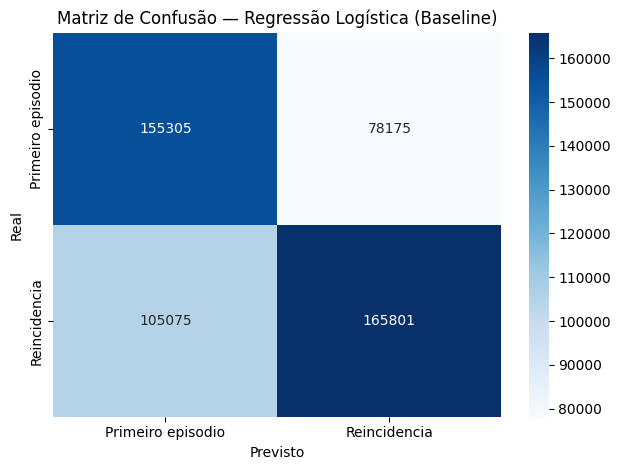

In [10]:
# Matriz de confusão — Regressão Logística
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Primeiro episodio','Reincidencia'],
            yticklabels=['Primeiro episodio','Reincidencia'])
plt.title('Matriz de Confusão — Regressão Logística (Baseline)')
plt.ylabel('Real'); plt.xlabel('Previsto')
plt.tight_layout(); plt.show()


Treinando Random Forest...
AUC-ROC: 0.7500  |  F1: 0.7070


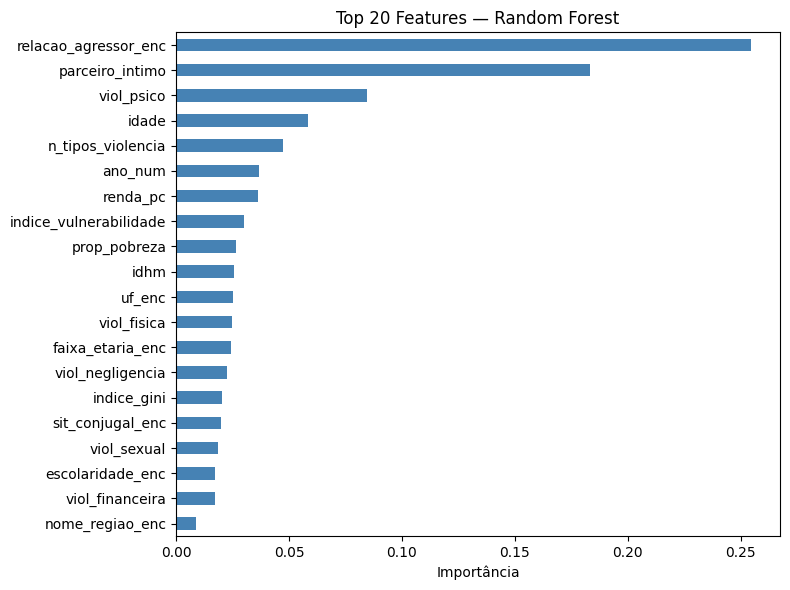

In [11]:
# Random Forest
print('Treinando Random Forest...')
rf = RandomForestClassifier(n_estimators=100, max_depth=15,
                            class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:,1]
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}  |  F1: {f1_score(y_test, y_pred_rf):.4f}')

feat_imp = pd.Series(rf.feature_importances_, index=TODAS_FEATURES)
feat_imp.nlargest(20).sort_values().plot(kind='barh', figsize=(8,6), color='steelblue')
plt.title('Top 20 Features — Random Forest')
plt.xlabel('Importância')
plt.tight_layout(); plt.show()


In [12]:
# XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Treinando XGBoost (scale_pos_weight={scale_pos:.2f})...')
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                    scale_pos_weight=scale_pos, random_state=42,
                    eval_metric='auc', verbosity=0, n_jobs=-1)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}  |  F1: {f1_score(y_test, y_pred_xgb):.4f}')


Treinando XGBoost (scale_pos_weight=0.86)...
AUC-ROC: 0.7503  |  F1: 0.7094


In [13]:
# LightGBM
print('Treinando LightGBM...')
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                      scale_pos_weight=scale_pos, random_state=42, verbosity=-1, n_jobs=-1)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:,1]
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_lgbm):.4f}  |  F1: {f1_score(y_test, y_pred_lgbm):.4f}')


Treinando LightGBM...
AUC-ROC: 0.7485  |  F1: 0.7093


In [14]:
# MLP (Rede Neural)
print('Treinando MLP...')
mlp = MLPClassifier(hidden_layer_sizes=(128,64), activation='relu', solver='adam',
                    alpha=0.001, max_iter=100, random_state=42,
                    early_stopping=True, validation_fraction=0.1, n_iter_no_change=10)
mlp.fit(X_train_sc, y_train)
y_pred_mlp = mlp.predict(X_test_sc)
y_prob_mlp = mlp.predict_proba(X_test_sc)[:,1]
print(f'Épocas: {mlp.n_iter_}  |  AUC-ROC: {roc_auc_score(y_test, y_prob_mlp):.4f}  |  F1: {f1_score(y_test, y_pred_mlp):.4f}')


Treinando MLP...
Épocas: 60  |  AUC-ROC: 0.7482  |  F1: 0.7282


In [15]:
# Tabela comparativa
resultados = pd.DataFrame({
    'Modelo':['Regressão Logística','Random Forest','XGBoost','LightGBM','MLP'],
    'AUC-ROC':[roc_auc_score(y_test,p) for p in [y_prob_lr,y_prob_rf,y_prob_xgb,y_prob_lgbm,y_prob_mlp]],
    'F1-Score':[f1_score(y_test,p) for p in [y_pred_lr,y_pred_rf,y_pred_xgb,y_pred_lgbm,y_pred_mlp]],
    'Brier':[brier_score_loss(y_test,p) for p in [y_prob_lr,y_prob_rf,y_prob_xgb,y_prob_lgbm,y_prob_mlp]],
}).round(4).sort_values('AUC-ROC', ascending=False)

print(resultados.to_string(index=False))


             Modelo  AUC-ROC  F1-Score  Brier
            XGBoost   0.7503    0.7094 0.2015
      Random Forest   0.7500    0.7070 0.2021
           LightGBM   0.7485    0.7093 0.2022
                MLP   0.7482    0.7282 0.2012
Regressão Logística   0.6930    0.6441 0.2222


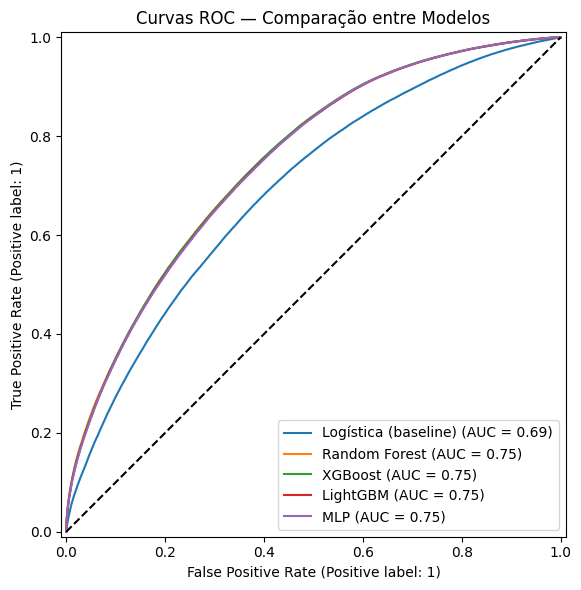

In [16]:
# Curvas ROC comparativas
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8,6))
for nome, y_prob in [
    ('Logística (baseline)', y_prob_lr),
    ('Random Forest', y_prob_rf),
    ('XGBoost', y_prob_xgb),
    ('LightGBM', y_prob_lgbm),
    ('MLP', y_prob_mlp),
]:
    RocCurveDisplay.from_predictions(y_test, y_prob, name=nome, ax=ax)
ax.plot([0,1],[0,1],'k--', label='Aleatório')
ax.set_title('Curvas ROC — Comparação entre Modelos')
plt.tight_layout(); plt.show()


In [17]:
# Análise de equidade por raça — melhor modelo (XGBoost)
print(f'{"Grupo":<15} {"AUC":>8} {"F1":>8} {"N":>10}')
print('-'*45)
auc_geral = roc_auc_score(y_test, y_prob_xgb)
f1_geral  = f1_score(y_test, y_pred_xgb)
print(f'{"GERAL":<15} {auc_geral:>8.4f} {f1_geral:>8.4f} {len(y_test):>10,}')
print('-'*45)

grupos_raca = df_model.loc[y_test.index, 'raca']
for grupo in ['Branca','Preta','Parda','Indigena','Ignorado']:
    mask = grupos_raca == grupo
    n = mask.sum()
    if n < 100: continue
    auc = roc_auc_score(y_test[mask], y_prob_xgb[mask])
    f1  = f1_score(y_test[mask], y_pred_xgb[mask])
    alerta = ' ⚠️' if abs(auc - auc_geral) > 0.05 else ''
    print(f'{grupo:<15} {auc:>8.4f} {f1:>8.4f} {n:>10,}{alerta}')


Grupo                AUC       F1          N
---------------------------------------------
GERAL             0.7503   0.7094    504,356
---------------------------------------------
Branca            0.7441   0.6995    217,507
Preta             0.7480   0.7512     46,370
Parda             0.7573   0.7086    206,795
Indigena          0.7196   0.6792      4,461
Ignorado          0.7478   0.7162     25,036


Calculando SHAP values (amostra de 3.000 registros)...


PermutationExplainer explainer: 3001it [03:27, 14.24it/s]                          


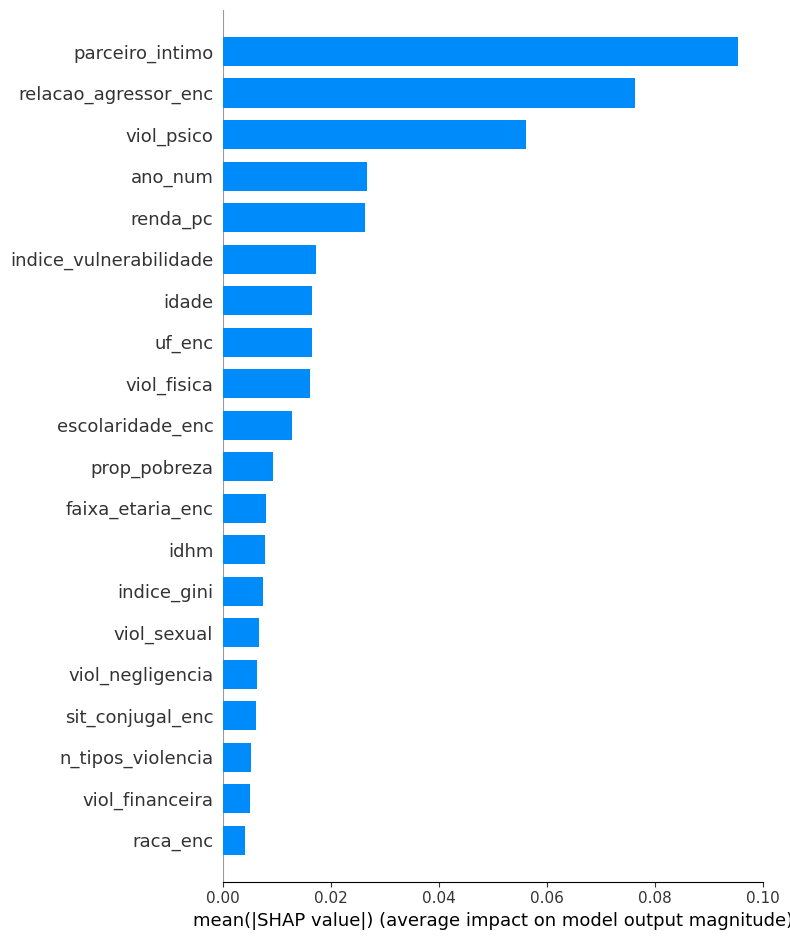

In [20]:
# SHAP — interpretabilidade do XGBoost
import shap

print('Calculando SHAP values (amostra de 3.000 registros)...')
amostra = X_test.sample(3000, random_state=42)

# Usar uma função callable para evitar incompatibilidade entre xgboost e SHAP
def pred_proba(data):
    return xgb.predict_proba(data)[:, 1]

try:
    masker = shap.maskers.Independent(X_test)
    explainer = shap.Explainer(pred_proba, masker, feature_names=TODAS_FEATURES)
    shap_values = explainer(amostra)
except Exception as e:
    print('Primeira tentativa com shap.Explainer falhou:', e)
    print('Tentando KernelExplainer com base reduzida...')
    background = shap.sample(X_test, 100, random_state=42)
    explainer = shap.KernelExplainer(pred_proba, background)
    shap_values = explainer.shap_values(amostra, nsamples=200)

shap.summary_plot(shap_values, amostra, feature_names=TODAS_FEATURES,
                  max_display=20, plot_type='bar', show=True)


In [21]:
# Salvar modelos localmente
import joblib

joblib.dump(lr,       os.path.join(PASTA_MODELOS, 'logistica.pkl'))
joblib.dump(rf,       os.path.join(PASTA_MODELOS, 'random_forest.pkl'))
joblib.dump(xgb,      os.path.join(PASTA_MODELOS, 'xgboost.pkl'))
joblib.dump(lgbm,     os.path.join(PASTA_MODELOS, 'lightgbm.pkl'))
joblib.dump(mlp,      os.path.join(PASTA_MODELOS, 'mlp.pkl'))
joblib.dump(scaler_m, os.path.join(PASTA_MODELOS, 'scaler.pkl'))
resultados.to_csv(os.path.join(PASTA_MODELOS, 'comparacao_modelos.csv'), index=False)

print('Modelos salvos em:', PASTA_MODELOS)
for f in os.listdir(PASTA_MODELOS):
    tam = os.path.getsize(os.path.join(PASTA_MODELOS, f)) / (1024*1024)
    print(f'  {f} ({tam:.1f} MB)')

print('\n Notebook concluído.')


Modelos salvos em: c:\Users\Wallace Luan\Downloads\Projeto - Modelo Preditivo\dados_violencia\modelos
  comparacao_modelos.csv (0.0 MB)
  lightgbm.pkl (1.0 MB)
  logistica.pkl (0.0 MB)
  mlp.pkl (0.3 MB)
  random_forest.pkl (190.5 MB)
  scaler.pkl (0.0 MB)
  xgboost.pkl (1.4 MB)

 Notebook concluído.
